In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [13]:
# Load datasets
complaints = pd.read_csv("/content/Complaints.csv")
suppliers = pd.read_csv("/content/suppliers.csv")
products = pd.read_csv("/content/products.csv")
customers = pd.read_csv("/content/customers.csv")

# Preview complaints table
print(complaints.head())

   complaint_id date_received customer_id product_batch_number  \
0          1034    2025-01-01  YumChicken    24-11-22-00:19-09   
1          1035    2025-01-01   Burgerhub    24-11-04-00:19-15   
2          1036    2025-01-01         DFC    24-11-13-22:04-04   
3          1037    2025-01-01         IQR    24-12-03-15:03-10   
4          1038    2025-01-02   Burgerhub    24-12-29-04:40-12   

      complaint_type  number_affected  amount_claimed_rands     status  
0  Missing portions                 3                    66  Resolved   
1  Missing portions                 4                    88  Resolved   
2  Missing portions                 2                    44  Resolved   
3        Off product                4                    88   Rejected  
4  Missing portions                 5                   110  Resolved   


In [8]:
# Check the shape of each table (rows, columns)

print("complaints:", complaints.shape)
print("suppliers:", suppliers.shape)
print("products:", products.shape)
print("customers:", customers.shape)

complaints: (149, 8)
suppliers: (5, 2)
products: (149, 7)
customers: (6, 2)


In [14]:
# Check data types and missing values

print(complaints.info())
print(suppliers.info())
print(products.info())
print(customers.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149 entries, 0 to 148
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   complaint_id          149 non-null    int64 
 1   date_received         149 non-null    object
 2   customer_id           149 non-null    object
 3   product_batch_number  149 non-null    object
 4   complaint_type        149 non-null    object
 5   number_affected       149 non-null    int64 
 6   amount_claimed_rands  149 non-null    int64 
 7   status                149 non-null    object
dtypes: int64(3), object(5)
memory usage: 9.4+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   supplier_id    5 non-null      int64 
 1   supplier_name  5 non-null      object
dtypes: int64(1), object(1)
memory usage: 212.0+ bytes
None
<class 'p

In [15]:
#convert date_received to proper format
complaints['date_received'] = pd.to_datetime(complaints['date_received'])

#Confirm it worked
print(complaints['date_received'].dtype)

datetime64[ns]


In [10]:

# Convert production_date and production_time to proper format

products['production_date'] = pd.to_datetime(products['production_date'])
products['production_time'] = pd.to_datetime(products['production_time'])

# Confirm it worked
print(products['production_date'].dtype)
print(products['production_time'].dtype)


datetime64[ns]
datetime64[ns]


/tmp/ipykernel_22189/1570376095.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  products['production_time'] = pd.to_datetime(products['production_time'])


In [18]:
# Basic summary statistics

print("Total complaints:", len(complaints))
print("Complaints by type:")
print(complaints['complaint_type'].value_counts())

Total complaints: 149
Complaints by type:
complaint_type
Missing portions     92
Off product          29
Small pieces         28
Name: count, dtype: int64


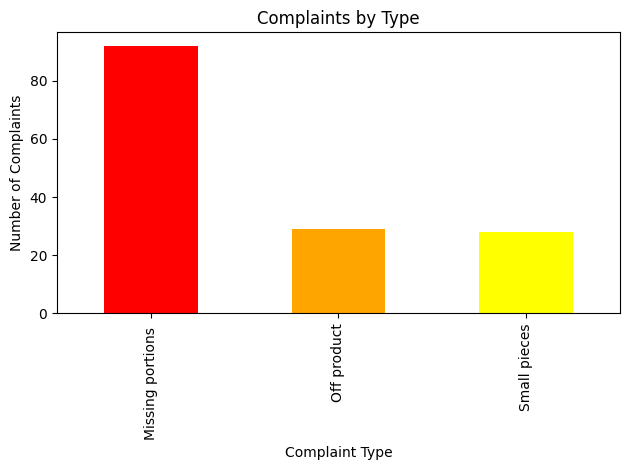

In [19]:
# Bar chart - Complaints by type

complaints['complaint_type'].value_counts().plot(
    kind='bar',
    title='Complaints by Type',
    color=['red', 'orange', 'yellow']
)
plt.xlabel('Complaint Type')
plt.ylabel('Number of Complaints')
plt.tight_layout()
plt.show()

In [30]:
# Merge complaints and products tables
merged = complaints.merge(products, on='product_batch_number')

# Basic Summary statistics
print("Total Complaints:", len(merged))
print("Complaints by Production Line")
print(merged['production_line'].value_counts())

Total Complaints: 149
Complaints by Production Line
production_line
5    45
1    41
3    36
2    19
4     8
Name: count, dtype: int64


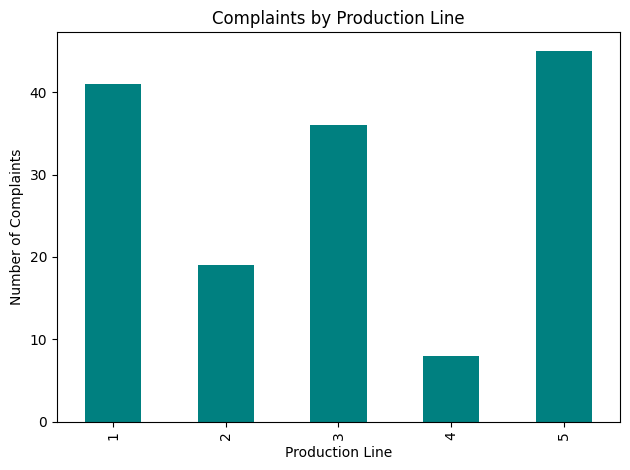

In [21]:
# Merge complaints and products tables
merged = complaints.merge(products, on='product_batch_number')

#Bar Chart - Complaints by production line
merged['production_line'].value_counts().sort_index().plot(
    kind='bar',
    title='Complaints by Production Line',
    color='teal'
)
plt.xlabel('Production Line')
plt.ylabel('Number of Complaints')
plt.tight_layout()
plt.show()

In [31]:
# Merge complaints and products tables
merged = complaints.merge(products, on='product_batch_number')

# Basic Summary statistics
print("Total Complaints:", len(merged))
print("Complaints by shift")
print(merged['shift'].value_counts())

Total Complaints: 149
Complaints by shift
shift
Night    100
Day       49
Name: count, dtype: int64


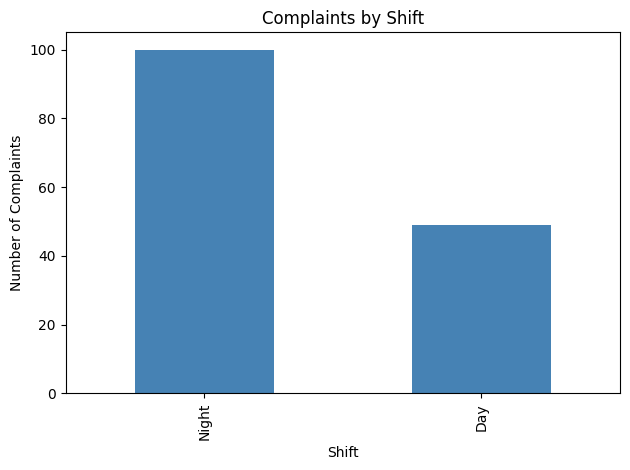

In [25]:
# Merge complaints and products tables
merged = complaints.merge(products, on='product_batch_number')

#Bar Chart - Complaints by Shift
merged['shift'].value_counts().plot(
    kind='bar',
    title='Complaints by Shift',
    color='steelblue'
)
plt.xlabel('Shift')
plt.ylabel('Number of Complaints')
plt.tight_layout()
plt.show()

In [32]:
# Merge complaints and products tables
merged = complaints.merge(products, on='product_batch_number')

# Basic Summary statistics
print("Total Complaints:", len(merged))
print("Complaints by Product Type")
print(merged['product_type'].value_counts())

Total Complaints: 149
Complaints by Product Type
product_type
16PCS      103
24PCS       26
24WNGS       9
16WNGS       7
4SPATCH      4
Name: count, dtype: int64


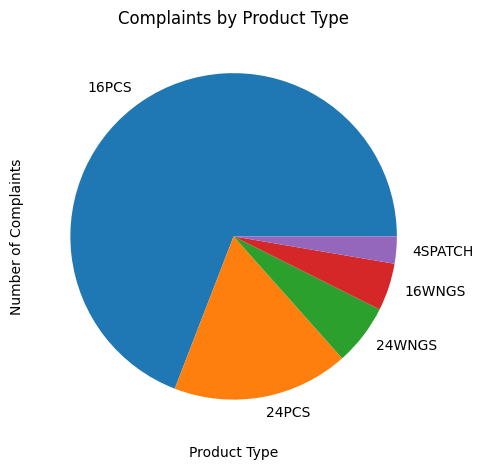

In [28]:
# Merge complaints and products tables
merged = complaints.merge(products, on='product_batch_number')

#Bar Chart - Complaints by product type
merged['product_type'].value_counts().plot(
    kind='pie',
    title='Complaints by Product Type',
    color=['green', 'blue', 'purple']
)
plt.xlabel('Product Type')
plt.ylabel('Number of Complaints')
plt.tight_layout()
plt.show()

In [37]:
# Merge complaints, products and suppliers tables
merged_three = complaints.merge(products, on='product_batch_number').merge(suppliers, on='supplier_id')

# Filter for small pieces only
small_pieces = merged_three[merged_three['complaint_type'] == 'Small pieces']

# Summary statistics
print("Small pieces complaints by supplier:")
print(small_pieces['supplier_name'].value_counts())


Small pieces complaints by supplier:
supplier_name
Hens Farm        13
Savannah's       10
Poultry Savy      3
White Poultry     1
Harties Farm      1
Name: count, dtype: int64


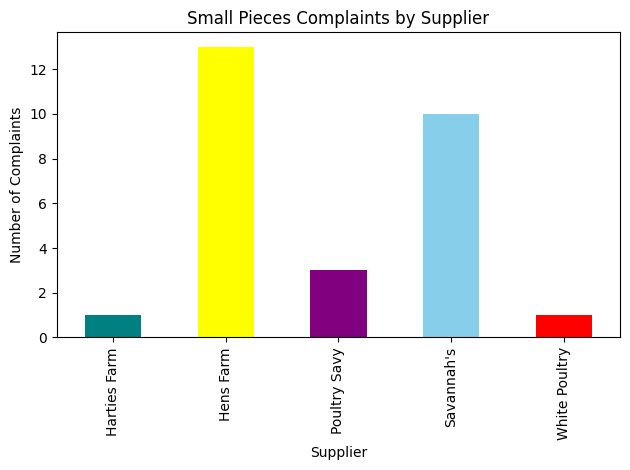

In [43]:
# Bar chart - small pieces complaints by supplier
small_pieces['supplier_name'].value_counts().sort_index().plot(
    kind= 'bar',
    title= 'Small Pieces Complaints by Supplier',
    color= ['teal', 'yellow', 'purple', 'skyblue', 'red']
)
plt.xlabel('Supplier')
plt.ylabel('Number of Complaints')
plt.tight_layout()
plt.show()

Monthly complaints trend:
month
2025-01    53
2025-02    47
2025-03    49
Freq: M, dtype: int64


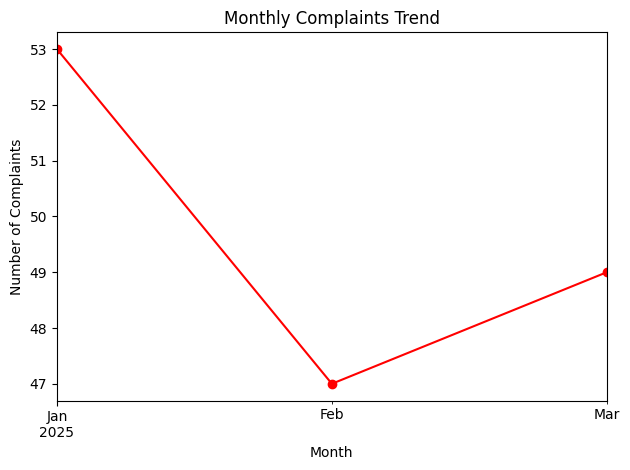

In [47]:
# Monthly trend
complaints['month'] = complaints['date_received'].dt.to_period('M')
monthly = complaints.groupby('month').size()

#Summary Statistics
print("Monthly complaints trend:")
print(monthly)

# Line chart
monthly.plot(
    kind='line',
    title='Monthly Complaints Trend',
    color='red',
    marker= 'o'
)
plt.xlabel('Month')
plt.ylabel('Number of Complaints')
plt.tight_layout()
plt.show()